In [73]:
from fileinput import filename
from tkinter import image_names

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping

import warnings
warnings.filterwarnings("ignore")


In [74]:
image_channe1 = 3
image_width = 60
image_height = 60
input_size = (image_width, image_height , image_channe1)

In [75]:
 class FormData():
     def __init__(self,dir):
         self.dir = dir

     def convert_numerical_labels(self,df):
         df["class"] = df["class"].replace({1:"cat",0:"dog"})
         return df

     def dataframe_formation(self):
         filenames = os.listdir(self.dir)
         categories = []
         for i in range(len(filenames)):
             if "dog" in filenames[i]:
                 categories.append(0)
             else:
                 categories.append(1)\

         df = pd.DataFrame({
         "Filename":filenames,
         "class" : categories
     })
         return df

In [76]:
train_dir = "dogs&cats/train"
train_obj = FormData(train_dir)
traininsg_df = train_obj.dataframe_formation()

In [77]:
print(traininsg_df.head())
print(len(train_dir))

       Filename  class
0  cat.2718.jpg      1
1  cat.3406.jpg      1
2  dog.1753.jpg      0
3  cat.1211.jpg      1
4  dog.3144.jpg      0
76


<Axes: xlabel='class'>

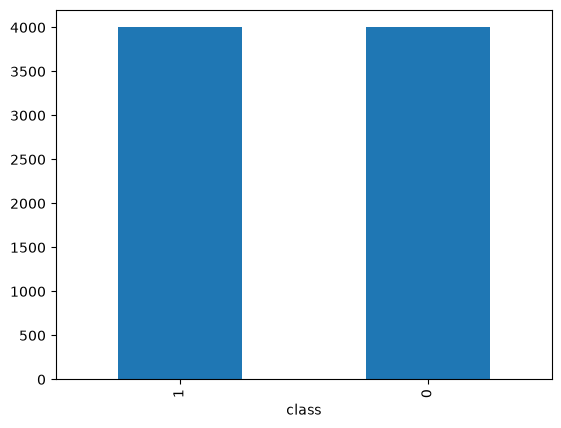

In [78]:
traininsg_df["class"].value_counts().plot.bar()

<class 'numpy.ndarray'>   (4, 4)
<class 'numpy.ndarray'>   (16,)


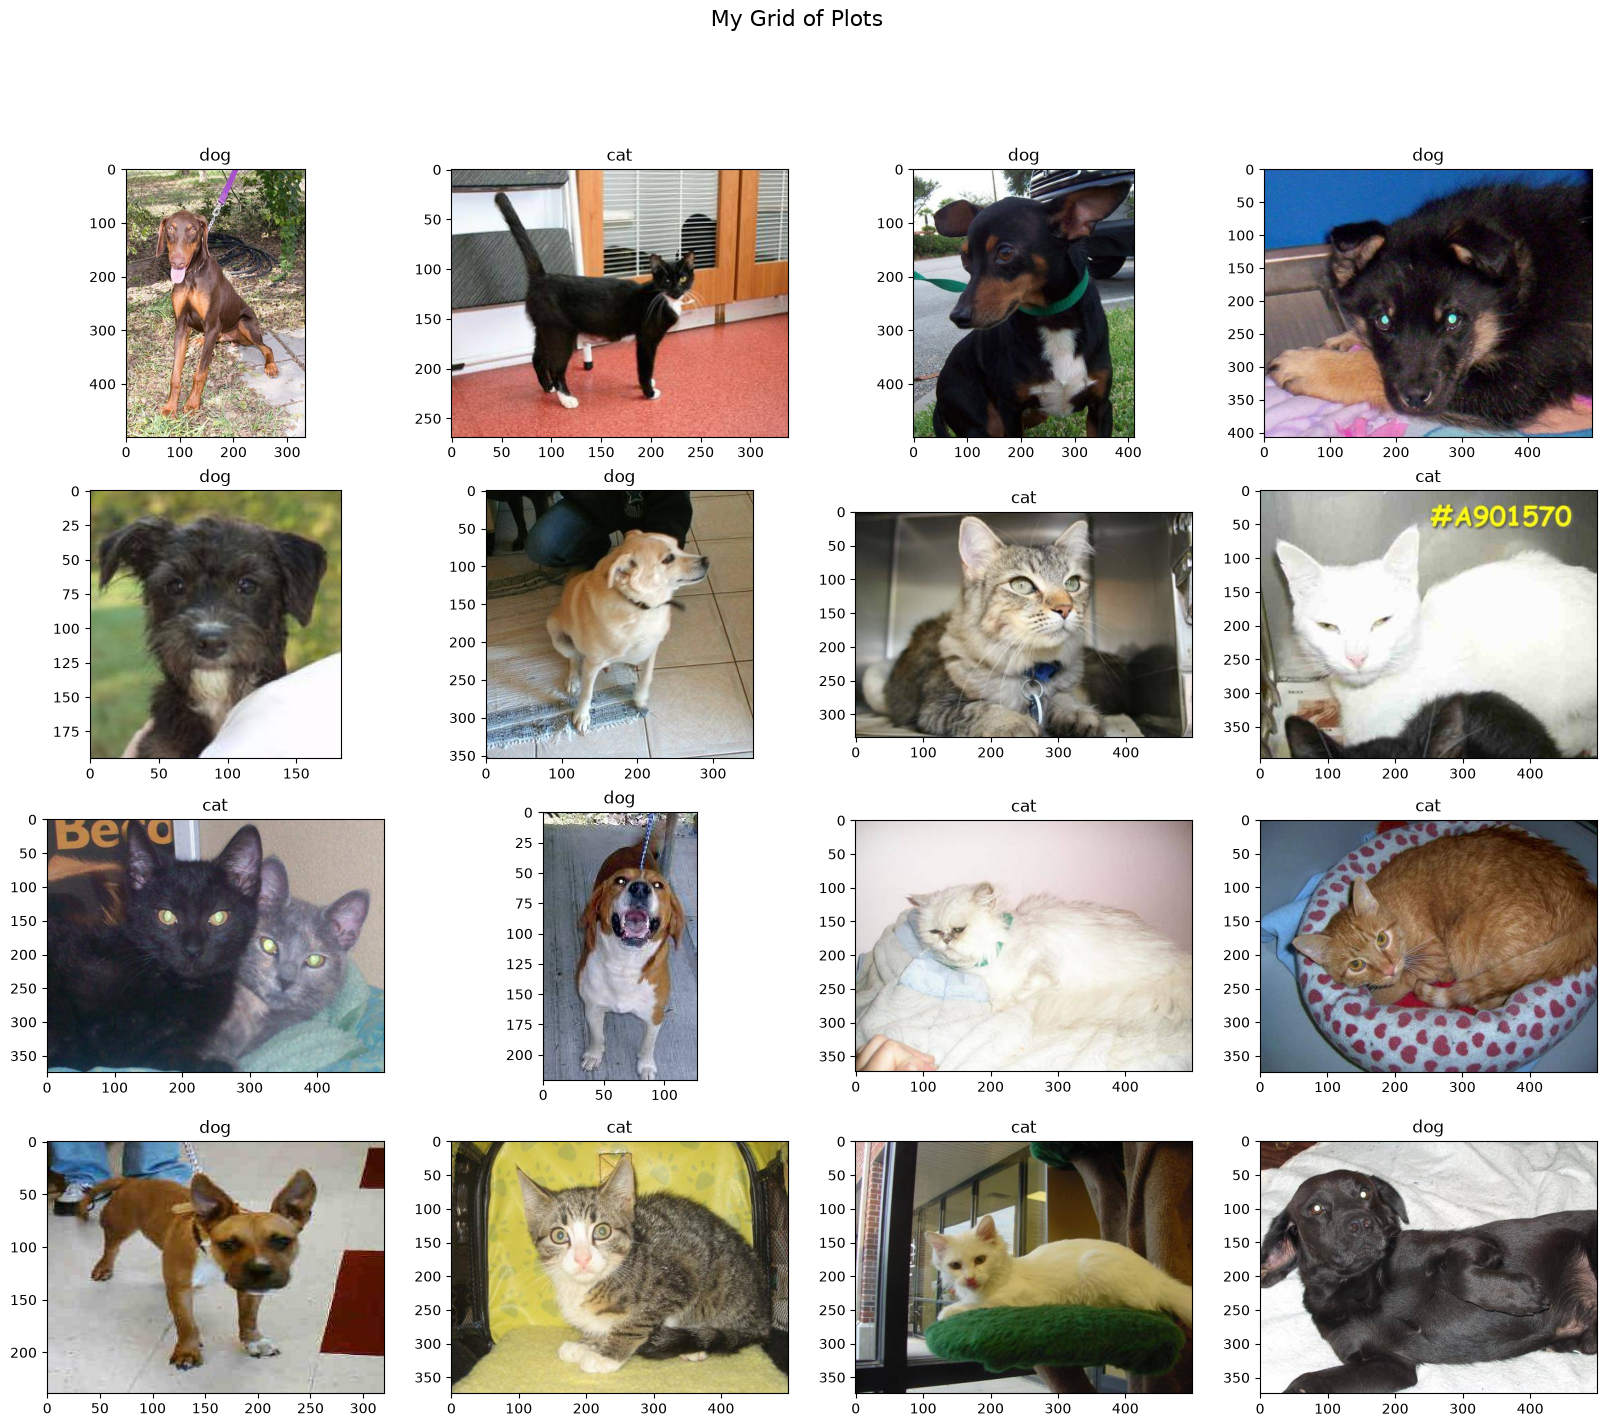

In [79]:
fig, axes = plt.subplots(4,4,figsize=(20,16))

print(type(axes),' ', axes.shape)

axes=axes.ravel()

print(type(axes),' ', axes.shape)

for i in np.arange(0,4*4):
    sample_row = traininsg_df.sample(n=1).iloc[0]
    image_path = os.path.join(train_dir,sample_row['Filename'])
    image = load_img(image_path)
    axes[i].imshow(image)
    if sample_row['class'] == 1:
        axes[i].set_title(f'cat')
    else:
        axes[i].set_title(f'dog')

fig.suptitle("My Grid of Plots", fontsize=16)
plt.show()

In [80]:
training_df = train_obj.convert_numerical_labels(traininsg_df)
training_df.head()

,Filename,class
0,cat.2718.jpg,cat
1,cat.3406.jpg,cat
2,dog.1753.jpg,dog
3,cat.1211.jpg,cat
4,dog.3144.jpg,dog


In [81]:
train_df, val_df = train_test_split(
    traininsg_df,
    test_size=0.20,
    random_state=7)

In [82]:
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255.0)

traindata = train_datagen.flow_from_dataframe(
    train_df,
    train_dir,
    x_col = 'Filename',
    y_col = 'class',
    target_size = (60,60),
    class_mode = 'categorical',
    batch_size = batch_size
)
print(len(traindata))

Found 6400 validated image filenames belonging to 2 classes.
200


In [83]:
val_datagen = ImageDataGenerator(rescale=1.0/255.0)

valdata = val_datagen.flow_from_dataframe(
    val_df,
    train_dir,
    x_col = 'Filename',
    y_col = 'class',
    target_size = (60,60),
    batch_size = batch_size,
    class_mode = 'categorical')

Found 1600 validated image filenames belonging to 2 classes.


{'cat': 0, 'dog': 1}
(32, 2)
(32, 60, 60, 3)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


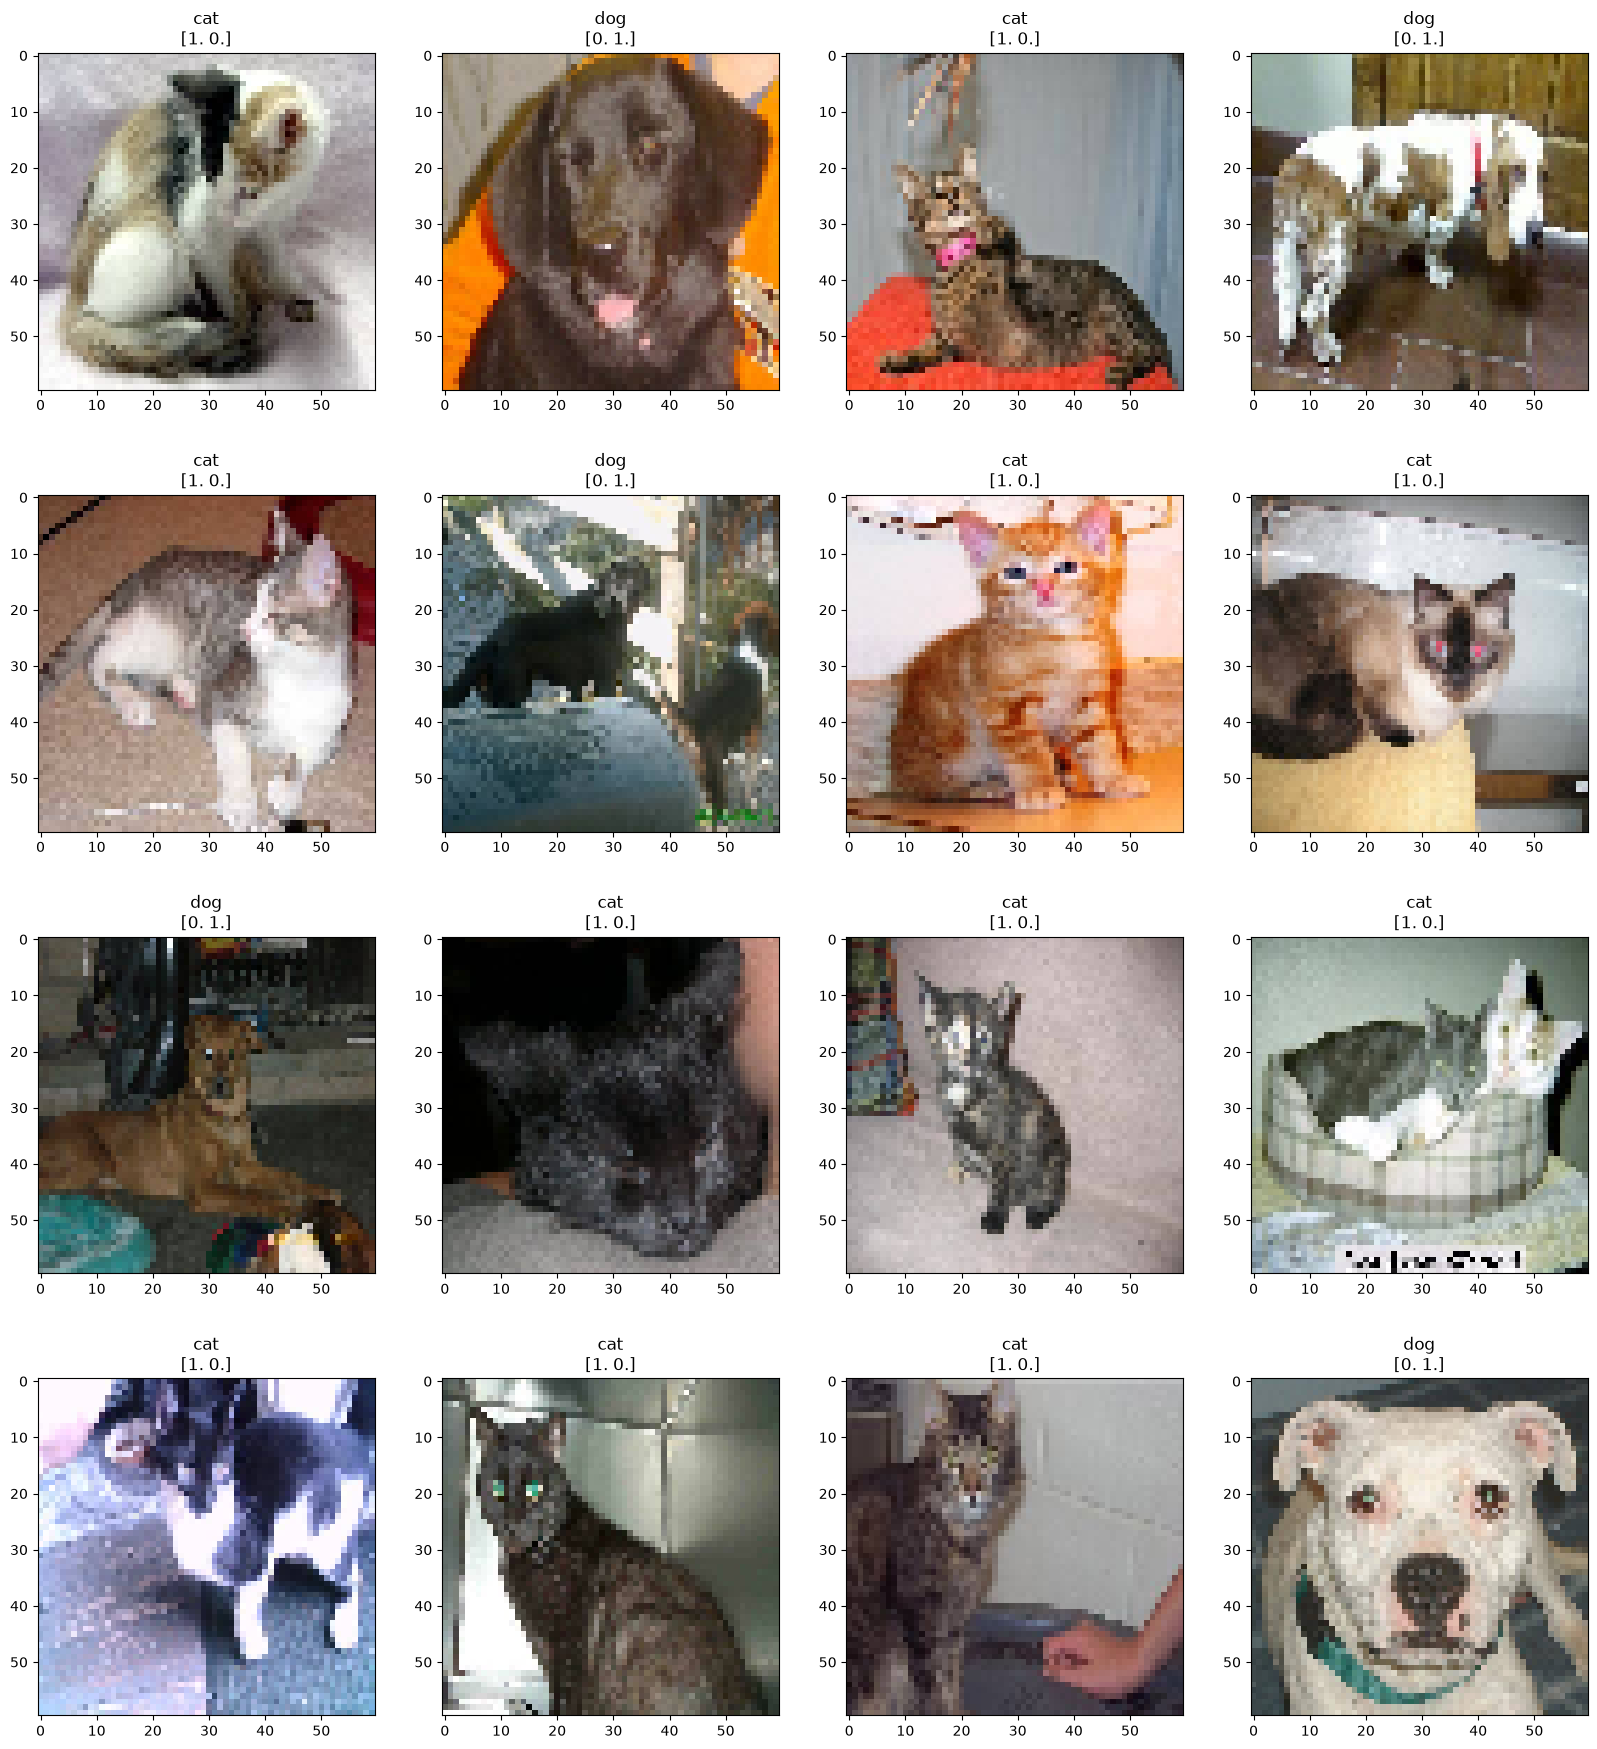

In [84]:
print(valdata.class_indices)

class_name = {0:'cat', 1:'dog'}

images,labels = next(traindata)

print(labels.shape)
print(images.shape)
print(type(labels))
print(type(images))

fig,axes = plt.subplots(4,4,figsize=(20,22))
axes = axes.ravel()

for i in np.arange(0,4*4):
    axes[i].imshow(images[i])
    index = np.argmax(labels[i])
    axes[i].set_title(f'{class_name[index]}\n{labels[i]}')

plt.show()

In [85]:
model = Sequential()

model.add(Conv2D(16, (3, 3), activation='relu', input_shape=input_size))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(2, activation='softmax'))

opt = Adam(learning_rate=0.0005)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 58, 58, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 29, 29, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 27, 27, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 466,594 (1.78 MB)

 Trainable params: 466,594 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

In [86]:
chceckpoint = ModelCheckpoint(filepath = 'Cat_Dog_classfication_model.keras',
                              monitor = 'val_loss',
                              mode = 'min',
                              save_best_only = True,
                              verbose = 1)

earlystop = EarlyStopping(monitor='val_loss',
                          restore_best_weights = True,
                          verbose = 1,
                          patience = 5,
                          min_delta = 0)

In [87]:
callbacks = [earlystop,chceckpoint]

In [113]:
print(val_df_len / batch_size)
print(np.ceil(val_df_len / batch_size))
print(int(np.ceil(val_df_len / batch_size)))

50.0
50.0
50


In [89]:
train_df_len = len(train_df)
val_df_len = len(val_df)

In [91]:
epochs = 25
history = model.fit(traindata,
                    epochs = epochs,
                    callbacks = callbacks,
                    validation_data = valdata,
                    validation_steps = int(np.ceil(val_df_len / batch_size)),
                    steps_per_epoch = int(np.ceil(train_df_len / batch_size)))

Epoch 1/25
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7611 - loss: 0.4900
Epoch 1: val_loss did not improve from 0.55371
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.7608 - loss: 0.4901 - val_accuracy: 0.7219 - val_loss: 0.5591
Epoch 2/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7773 - loss: 0.4590
Epoch 2: val_loss improved from 0.55371 to 0.53281, saving model to Cat_Dog_classfication_model.keras

Epoch 2: finished saving model to Cat_Dog_classfication_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.7773 - loss: 0.4590 - val_accuracy: 0.7362 - val_loss: 0.5328
Epoch 3/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.7970 - loss: 0.4239
Epoch 3: val_loss did not improve from 0.53281
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - accuracy: 0.7970 - loss: 0.4239 - val_accuracy: 0.7188 - val_loss: 0.5676
Epoch 4/25
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8249 - loss: 0.3893
Epoch 4: val_loss did not impr

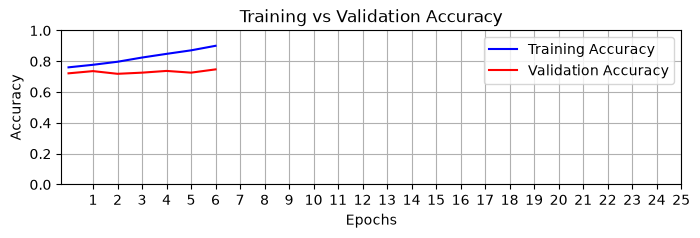

In [92]:
plt.figure(figsize=(8, 2))
plt.plot(history.history['accuracy'], label="Training Accuracy", color='b')
plt.plot(history.history['val_accuracy'], label="Validation Accuracy", color='r')
plt.xticks(np.arange(1, epochs + 1, 1))
plt.yticks(np.arange(0, 1.1, 0.2))
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [94]:
pred = model.predict(valdata,steps=int(np.ceil(1600/batch_size)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


In [95]:
class_name = {1:'dog',0:'cat'}

val_df['predicted'] = np.argmax(pred, axis=-1)
val_df['confidence'] = np.max(pred, axis=-1)
val_df['predicted'] = val_df['predicted'].replace(class_name)

images,labels = next(valdata)

print(pred.shape)
print(pred[0])
print(type(images[0]))
print(images[0])
print(val_df.head())
print(len(valdata))

(1600, 2)
[0.2689086  0.73109144]
<class 'numpy.ndarray'>
[[[0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]
  ...
  [0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]]

 [[0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]
  ...
  [0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]]

 [[0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]
  ...
  [0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]
  [0.00392157 0.00392157 0.00392157]]

 ...

 [[0.2784314  0.16470589 0.17254902]
  [0.28235295 0.18039216 0.18431373]
  [0.3529412  0.24705884 0.21960786]
  ...
  [0.28627452 0.21176472 0.19607845]
  [0.3137255  0.2392157  0.21568629]
  [0.22352943 0.16470589 0.13725491]]

 [[0.454902   0.

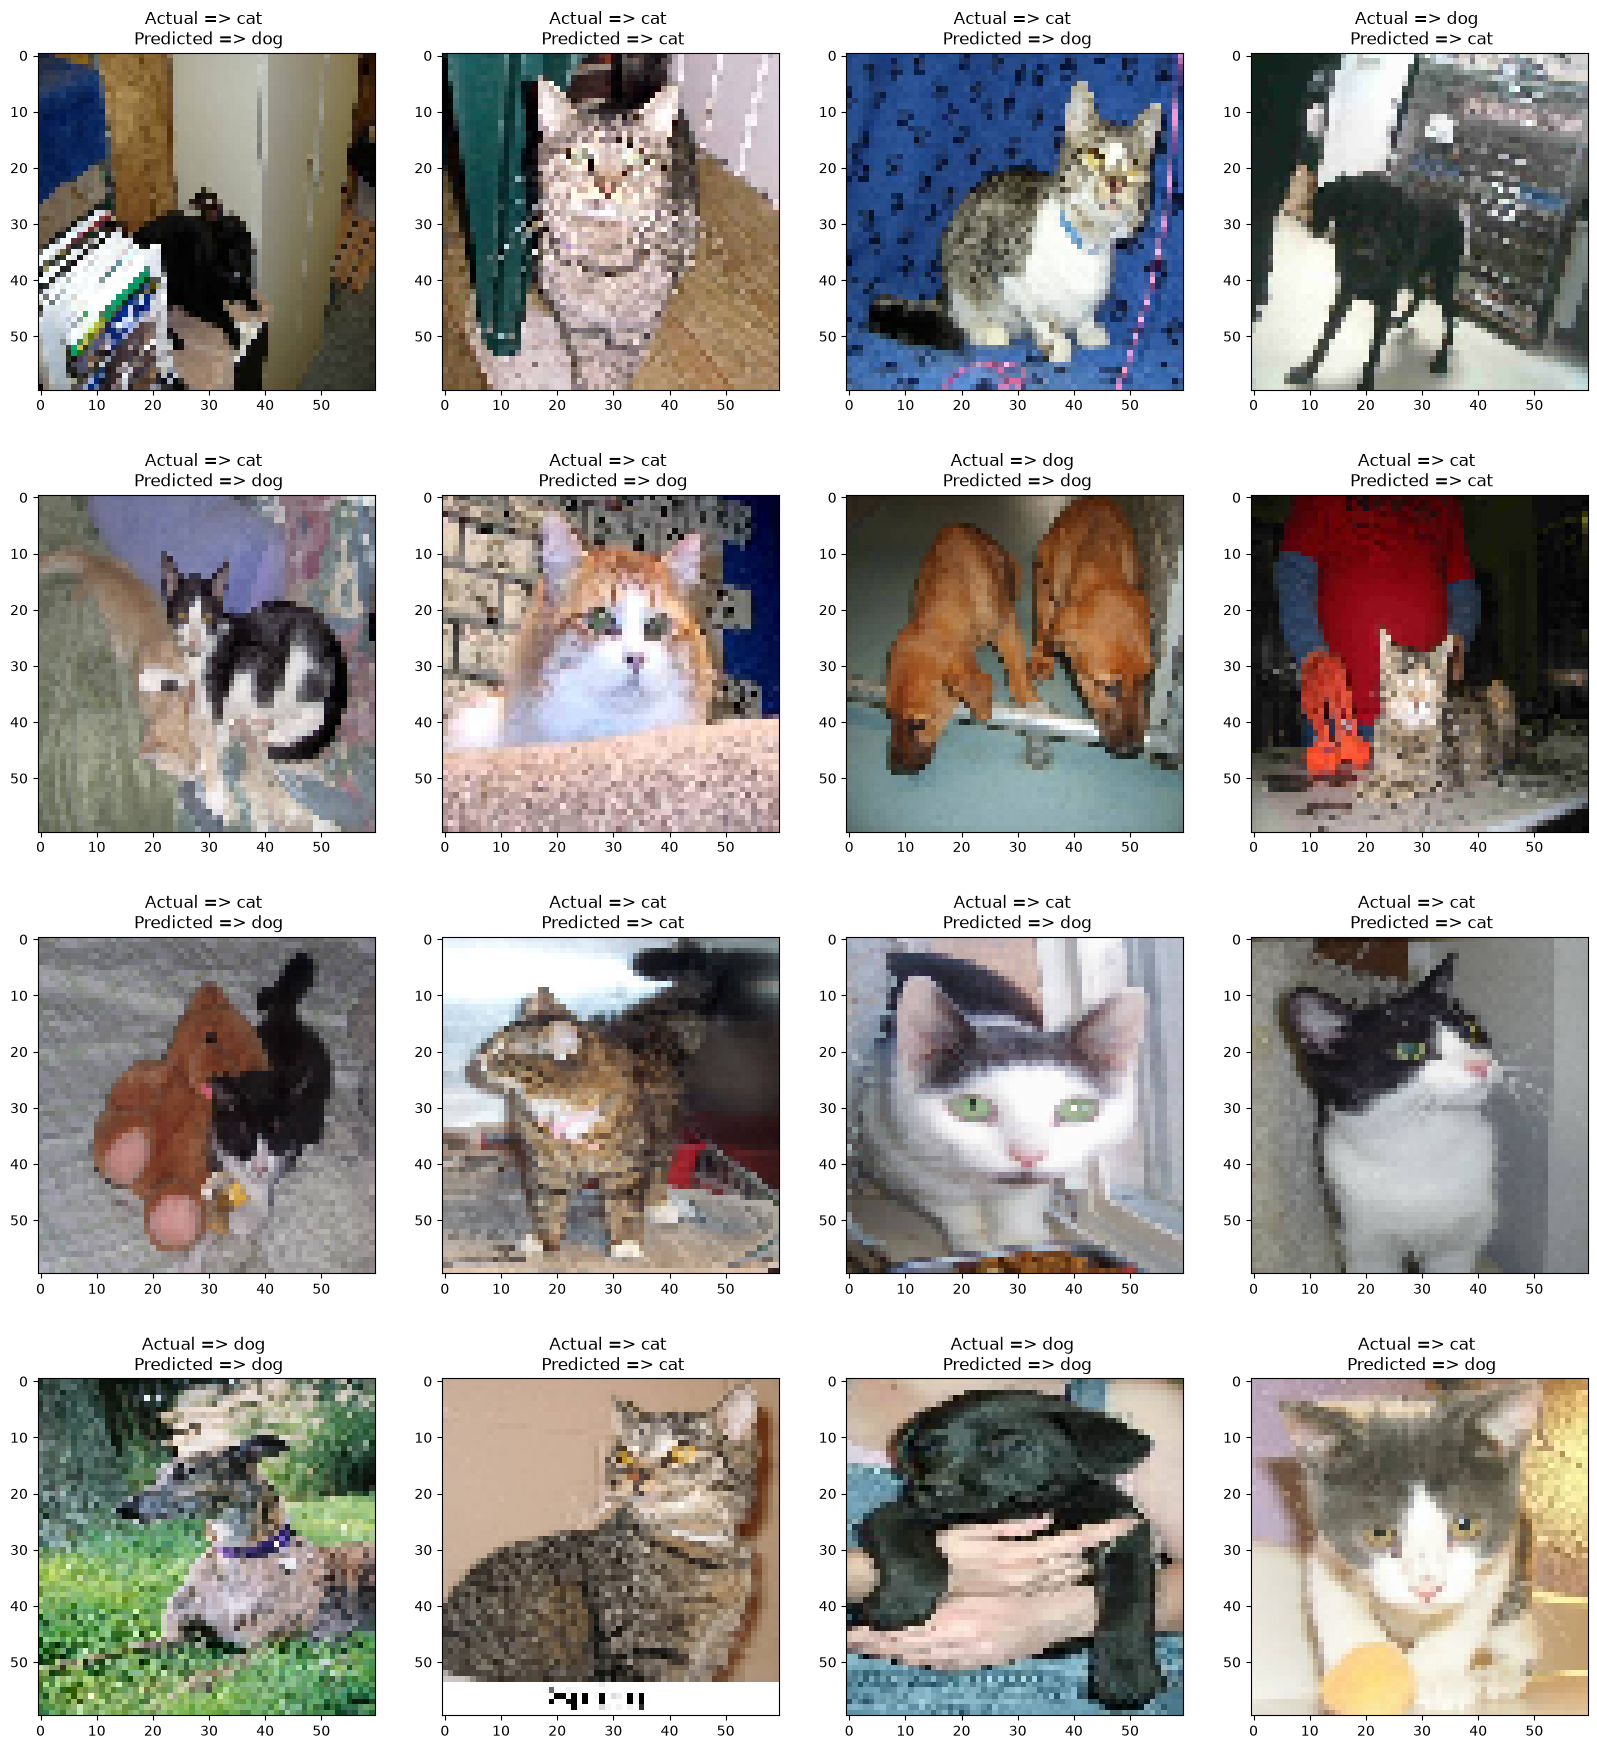

In [104]:
sample_test = val_df.head(16).reset_index(drop=True)

fig,axes = plt.subplots(4,4,figsize=(20,22))
axes=axes.ravel()

for i, row in sample_test.iterrows():
    filename = row['Filename']
    predicted = row['predicted']
    actual = row['class']

    image = load_img((train_dir + '/' + filename), target_size=input_size)
    axes[i].imshow(image)
    axes[i].set_title(f'Actual => {actual} \n Predicted => {predicted}')

plt.show()